In [16]:
#Load and inspect the dataset
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/karun/OneDrive/Desktop/Machine learning/ML Assignment/METABRIC_RNA_Mutation.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

# Missing values
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

C:\Users\karun\AppData\Local\Temp\ipykernel_15716\152939876.py:5: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/karun/OneDrive/Desktop/Machine learning/ML Assignment/METABRIC_RNA_Mutation.csv")


Shape: (1904, 693)
   patient_id  age_at_diagnosis type_of_breast_surgery    cancer_type  \
0           0             75.65             MASTECTOMY  Breast Cancer   
1           2             43.19      BREAST CONSERVING  Breast Cancer   
2           5             48.87             MASTECTOMY  Breast Cancer   
3           6             47.68             MASTECTOMY  Breast Cancer   
4           8             76.97             MASTECTOMY  Breast Cancer   

                        cancer_type_detailed cellularity  chemotherapy  \
0           Breast Invasive Ductal Carcinoma         NaN             0   
1           Breast Invasive Ductal Carcinoma        High             0   
2           Breast Invasive Ductal Carcinoma        High             1   
3  Breast Mixed Ductal and Lobular Carcinoma    Moderate             1   
4  Breast Mixed Ductal and Lobular Carcinoma        High             1   

  pam50_+_claudin-low_subtype  cohort er_status_measured_by_ihc  ... mtap_mut  \
0               

In [17]:
#Select numerical molecular features
# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

print("Numerical features:", numeric_df.shape[1])

# Remove patient ID
if "patient_id" in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=["patient_id"])

# Fill missing values
numeric_df = numeric_df.fillna(numeric_df.median())

print("Final data shape:", numeric_df.shape)

Numerical features: 503
Final data shape: (1904, 502)


PC1 variance: 0.07852992650995885
PC2 variance: 0.06679787452681556
Total variance: 0.1453278010367744


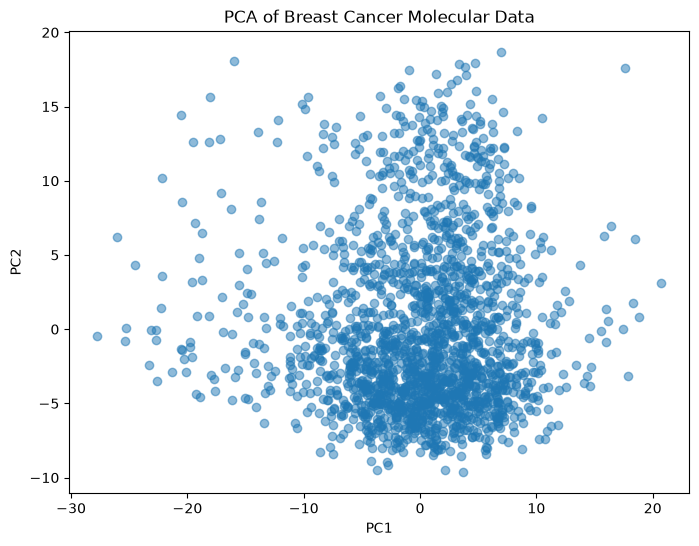

In [18]:
#PCA — important for high-dimensional molecular data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PC1 variance:", pca.explained_variance_ratio_[0])
print("PC2 variance:", pca.explained_variance_ratio_[1])
print("Total variance:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Breast Cancer Molecular Data")
plt.show()

In [19]:
#K-Means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df["Cluster"].value_counts())

Cluster
1    882
2    631
0    391
Name: count, dtype: int64


C:\Users\karun\AppData\Local\Temp\ipykernel_15716\2731116816.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Cluster"] = clusters


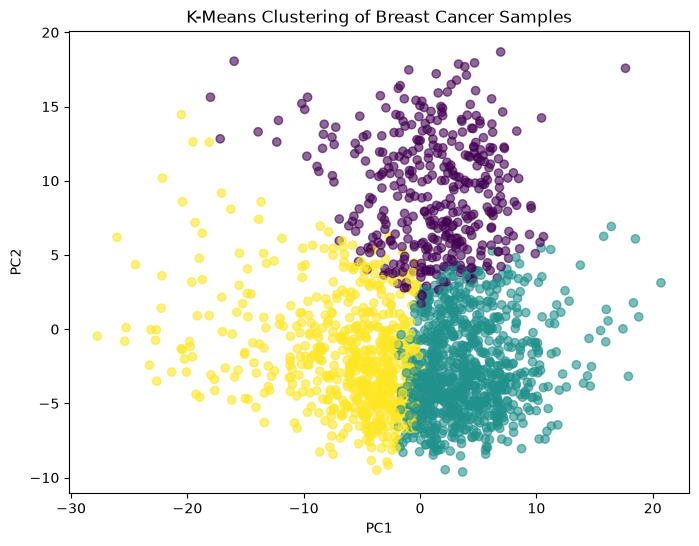

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering of Breast Cancer Samples")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Remove missing target rows
data = df.dropna(subset=["type_of_breast_surgery"]).copy()

X = numeric_df.loc[data.index]
y = data["type_of_breast_surgery"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.76657824933687

Classification Report:
                   precision    recall  f1-score   support

BREAST CONSERVING       0.79      0.57      0.66       151
       MASTECTOMY       0.76      0.90      0.82       226

         accuracy                           0.77       377
        macro avg       0.77      0.73      0.74       377
     weighted avg       0.77      0.77      0.76       377



Cluster counts:
0    1292
1     461
2     151
Name: count, dtype: int64


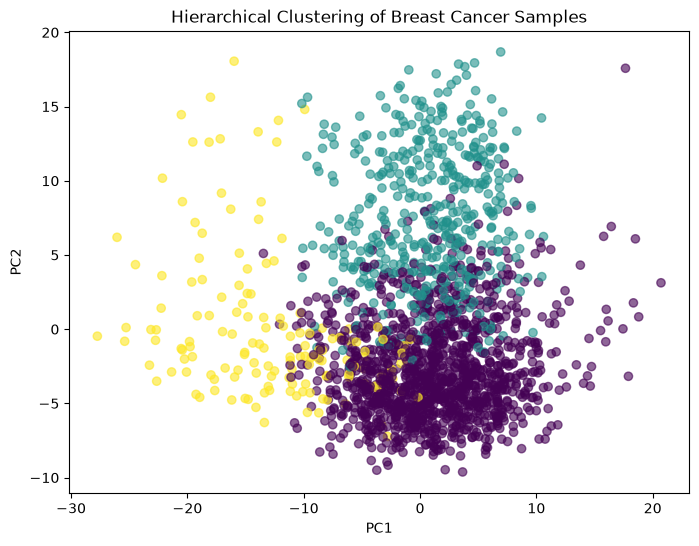

In [22]:
#Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

hierarchical = AgglomerativeClustering(
    n_clusters=3
)

hier_clusters = hierarchical.fit_predict(X_scaled)

print("Cluster counts:")
print(pd.Series(hier_clusters).value_counts())

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hier_clusters,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering of Breast Cancer Samples")
plt.show()

In [23]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7055702917771883

Classification Report:
                   precision    recall  f1-score   support

BREAST CONSERVING       0.63      0.63      0.63       151
       MASTECTOMY       0.75      0.76      0.75       226

         accuracy                           0.71       377
        macro avg       0.69      0.69      0.69       377
     weighted avg       0.71      0.71      0.71       377



c:\Users\karun\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
#SVM
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.6180371352785146

Classification Report:
                   precision    recall  f1-score   support

BREAST CONSERVING       0.71      0.08      0.14       151
       MASTECTOMY       0.61      0.98      0.75       226

         accuracy                           0.62       377
        macro avg       0.66      0.53      0.45       377
     weighted avg       0.65      0.62      0.51       377

